In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 11. キャップストーン — 1つの回帰を「四つの視点」で

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語、数式に日本語を入れない。

## この章で分かること

- analytics シリーズ共通の **同一データ**(`make_capstone_dataset`)を、本書の **機械学習の視点** で正しく解く
- そのうえで、まったく同じ正則化回帰(リッジ)が **四つの視点** で同じ解に到達することを **数値で確認** する:
  - **機械学習**: 経験リスク最小化 + 交差検証でモデル選択
  - **線形代数**: 正規方程式 / SVD による閉形式解(姉妹本 [`linear_algebra`](../linear_algebra/))
  - **ベイズ**: ガウス事前のもとでの MAP 推定(姉妹本 [`bayesian`](../bayesian/))
  - **勾配降下**: 重み減衰つき GD が同じ解へ収束(姉妹本 [`neural_net`](../neural_net/))
- 仕上げに **モデル選択チートシート**(いつどのモデルを使うか)

姉妹本それぞれの「三つの視点」キャップストーンに、本書が **第四の視点(古典ML の実務)** を足す回です。

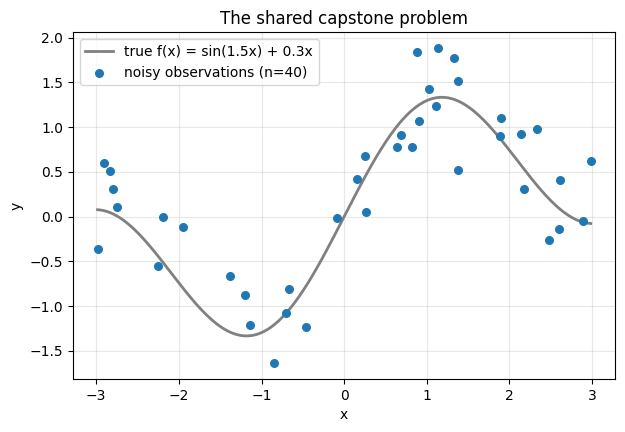

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, plotting

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

# The SAME generator that every analytics book uses for its capstone.
x, y = datasets.make_capstone_dataset(n=40, seed=0)
grid = np.linspace(x.min(), x.max(), 300)
true = np.sin(1.5 * grid) + 0.3 * grid   # the underlying curve (unknown to the model)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid, true, color="gray", lw=2, label="true f(x) = sin(1.5x) + 0.3x")
ax.scatter(x, y, s=30, color="#1f77b4", zorder=3, label="noisy observations (n=40)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("The shared capstone problem"); plt.show()

## 1. 機械学習の視点 — 正しく検証してモデルを選ぶ

データは 40 点と少ないので、単一の train/test 分割は不安定です。**交差検証 (CV)** で複数モデル族を比べ、
RMSE が最小のものを選びます(本書 04 章の原則: モデル数より正しい評価)。

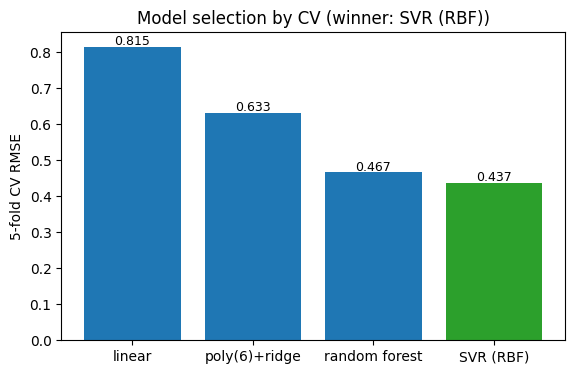

{'linear': 0.815, 'poly(6)+ridge': 0.633, 'random forest': 0.467, 'SVR (RBF)': 0.437}


In [3]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

X = x[:, None]
cv = KFold(n_splits=5, shuffle=True, random_state=0)

candidates = {
    "linear": LinearRegression(),
    "poly(6)+ridge": make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=1.0)),
    "random forest": RandomForestRegressor(n_estimators=300, random_state=0),
    "SVR (RBF)": make_pipeline(StandardScaler(), SVR(C=10, gamma="scale")),
}
cv_rmse = {}
for name, model in candidates.items():
    neg_mse = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    cv_rmse[name] = float(np.sqrt(-neg_mse).mean())

best = min(cv_rmse, key=cv_rmse.get)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(list(cv_rmse), list(cv_rmse.values()),
       color=["#1f77b4" if k != best else "#2ca02c" for k in cv_rmse])
ax.set_ylabel("5-fold CV RMSE"); ax.set_title(f"Model selection by CV (winner: {best})")
for i, v in enumerate(cv_rmse.values()):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.show()
print({k: round(v, 3) for k, v in cv_rmse.items()})

### バイアス-バリアンス: 多項式の次数

なぜ次数 6 + リッジを選ぶのか。次数を上げると訓練誤差は下がり続けますが、CV 誤差は途中で増えます(過学習)。
下の Plotly スライダー(静的 HTML 可)で次数を動かして確認してください。

In [4]:
plotting.plotly_model_complexity(x, y, degrees=range(1, 13), test_size=0.3, seed=0).show()

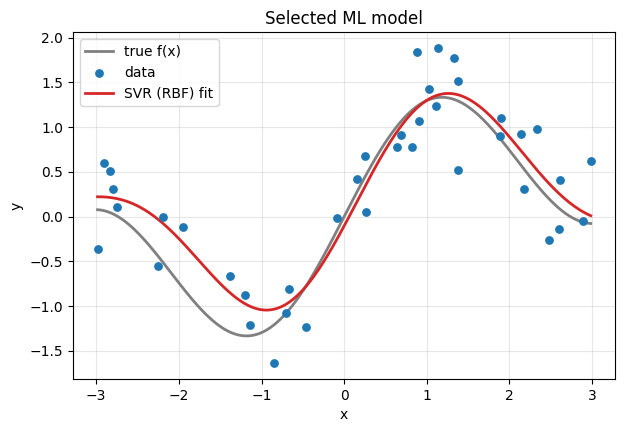

In [5]:
# Fit the selected model on all data and overlay the fit on the true curve.
best_model = candidates[best].fit(X, y)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(grid, true, color="gray", lw=2, label="true f(x)")
ax.scatter(x, y, s=28, color="#1f77b4", zorder=3, label="data")
ax.plot(grid, best_model.predict(grid[:, None]), color="#d62728", lw=2, label=f"{best} fit")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Selected ML model"); plt.show()

## 2. 同じリッジ回帰、四つの導出

ここからが横断のハイライト。次数 6 の **標準化した多項式特徴** $\Phi$ にリッジ回帰を当てます。
目的関数は

$$
\min_{w}\ \lVert y_c - \Phi w \rVert^2 + \alpha \lVert w \rVert^2
$$

($y_c$ は中心化した $y$)。この **唯一の解** $w$ に、四つの視点がそれぞれ到達します。

In [6]:
from sklearn.linear_model import Ridge

degree, alpha = 6, 1.0
Phi = PolynomialFeatures(degree, include_bias=False).fit_transform(X)
Phi_s = StandardScaler().fit_transform(Phi)   # standardized design matrix
yc = y - y.mean()                              # center target (intercept handled separately)
p = Phi_s.shape[1]

# --- Lens A: machine learning (scikit-learn Ridge, no intercept on centered data) ---
w_ml = Ridge(alpha=alpha, fit_intercept=False).fit(Phi_s, yc).coef_

# --- Lens B: linear algebra (normal equations, then SVD) ---
w_normal = np.linalg.solve(Phi_s.T @ Phi_s + alpha * np.eye(p), Phi_s.T @ yc)
U, S, Vt = np.linalg.svd(Phi_s, full_matrices=False)
w_svd = Vt.T @ ((S / (S**2 + alpha)) * (U.T @ yc))

# --- Lens D: gradient descent with weight decay (the neural-net view) ---
smax = np.linalg.norm(Phi_s, 2)
lr = 1.0 / (2 * (smax**2 + alpha))   # guaranteed-stable step size
w_gd = np.zeros(p); losses = []
for _ in range(20000):
    err = Phi_s @ w_gd - yc
    losses.append(float(np.sum(err**2) + alpha * np.sum(w_gd**2)))
    w_gd -= lr * (2 * (Phi_s.T @ err) + 2 * alpha * w_gd)

print("max |w| difference vs scikit-learn Ridge:")
print(f"  normal equations : {np.max(np.abs(w_ml - w_normal)):.2e}")
print(f"  SVD              : {np.max(np.abs(w_ml - w_svd)):.2e}")
print(f"  gradient descent : {np.max(np.abs(w_ml - w_gd)):.2e}")

max |w| difference vs scikit-learn Ridge:
  normal equations : 1.97e-15
  SVD              : 8.10e-15
  gradient descent : 1.30e-14


### Lens C: ベイズ(MAP = リッジ)

重み $w$ にガウス事前 $w \sim \mathcal{N}(0, \tau^2 I)$、観測に $y \sim \mathcal{N}(\Phi w, \sigma^2 I)$ を置くと、
事後最大化(MAP)は

$$
\min_w\ \frac{1}{\sigma^2}\lVert y_c - \Phi w\rVert^2 + \frac{1}{\tau^2}\lVert w\rVert^2
\;\;\Longleftrightarrow\;\;
\alpha = \frac{\sigma^2}{\tau^2}
$$

すなわち **リッジの罰則 $\alpha$ = ノイズ分散 / 事前分散**。正則化の強さは「事前の強さ」に他なりません。
だから上の $w_{\text{ml}}$ はそのまま **MAP 推定値** でもあります(姉妹本 `bayesian` の視点)。

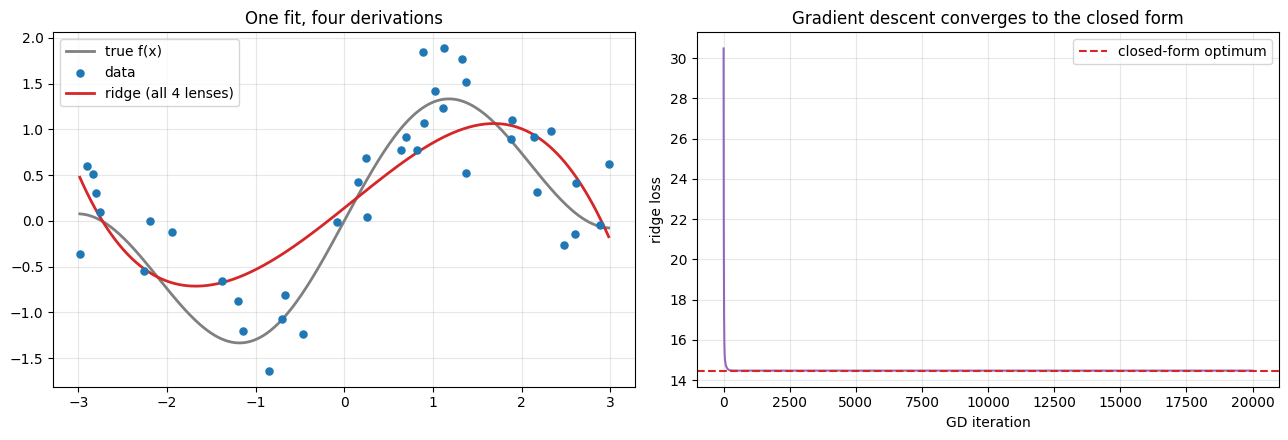

In [7]:
# All four derivations give the SAME weights -> a single curve.
def predict_ridge(xq):
    Phiq = PolynomialFeatures(degree, include_bias=False).fit(X).transform(xq[:, None])
    Phiq_s = StandardScaler().fit(Phi).transform(Phiq)
    return Phiq_s @ w_ml + y.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(grid, true, color="gray", lw=2, label="true f(x)")
axes[0].scatter(x, y, s=26, color="#1f77b4", zorder=3, label="data")
axes[0].plot(grid, predict_ridge(grid), color="#d62728", lw=2, label="ridge (all 4 lenses)")
axes[0].set_title("One fit, four derivations"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(losses, color="#9467bd"); axes[1].set_xlabel("GD iteration"); axes[1].set_ylabel("ridge loss")
axes[1].axhline(float(np.sum((Phi_s @ w_ml - yc) ** 2) + alpha * np.sum(w_ml**2)),
                color="#d62728", ls="--", label="closed-form optimum")
axes[1].set_title("Gradient descent converges to the closed form"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 四つの視点のまとめ

| 視点 | 何を最適化/計算するか | 解 |
|---|---|---|
| **機械学習**(本書) | 経験リスク + 罰則を CV でチューニング | `Ridge(alpha)` を CV で選ぶ |
| **線形代数** | 正規方程式 $(\Phi^\top\Phi + \alpha I)w=\Phi^\top y_c$ / SVD | 閉形式 $w=V\frac{S}{S^2+\alpha}U^\top y_c$ |
| **ベイズ** | ガウス事前のもとでの事後最大化 | MAP、$\alpha=\sigma^2/\tau^2$ |
| **勾配降下** | 同じ損失を反復降下(重み減衰=L2) | 同じ $w$ に収束 |

**同じ問題・同じ解。** 違うのは「どの言語で語るか」だけ。正則化は線形代数では数値安定化、
ベイズでは事前、深層学習では重み減衰 — すべて同一の $\alpha\lVert w\rVert^2$ です。

## 3. モデル選択チートシート

| モデル | 仮説の形 | スケーリング | 解釈性 | 強み / 使いどころ |
|---|---|---|---|---|
| 線形 / ロジスティック | 線形(超平面) | 必要(正則化時) | 高(係数) | ベースライン・係数解釈・高次元疎データ |
| Ridge / Lasso / ElasticNet | 線形 + 罰則 | 必要 | 高 | 多重共線性・特徴選択(Lasso) |
| 決定木 | 軸平行の階段 | 不要 | 中(可視化) | 非線形・相互作用・前処理少 |
| ランダムフォレスト | 木の平均(バギング) | 不要 | 中(重要度) | 頑健な汎用既定値・表データ |
| 勾配ブースティング | 木の逐次和 | 不要 | 中 | 表データで高精度(Kaggle 定番) |
| SVM (RBF) | 最大マージン + カーネル | **必須** | 低 | 中規模・非線形・きれいな境界 |
| k-NN | 近傍多数決 | **必須** | 低 | 単純ベースライン・局所構造 |
| k-means / GMM | クラスタ中心 / 混合 | 必要 | 中 | 教師なしのグループ発見 |

> 実務の既定手順: **線形/ロジスティックでベースライン → 勾配ブースティング or RF で精度 → 正しく評価(04)→ 解釈(09)→ パイプライン化(10)**。

## 4. まとめ

- 少データでも **交差検証** で正直にモデルを選べば、過学習せず妥当なモデル(次数 6 + リッジ)に行き着く。
- そのリッジ解は **機械学習・線形代数・ベイズ・勾配降下** の四つの導出で **数値的に一致** する。
  正則化 = 数値安定化 = 事前 = 重み減衰。
- モデル選びはチートシートの目安 + **必ず評価で確認**。万能モデルは無い。
- 本書の流れ(定式化 01 → 前処理/リーク 02 → モデル 03/05/06 → 評価 04 → 教師なし 07 → 時系列 08 → 解釈 09 → 運用 10)を、この 1 問が束ねている。

## 関連(姉妹本の同一キャップストーン)

- [`linear_algebra`](../linear_algebra/) — 同じ問題を SVD / 最小二乗の視点で(本章 Lens B)。
- [`bayesian`](../bayesian/) — 同じ問題を事後分布 / MAP の視点で(本章 Lens C)。
- [`neural_net`](../neural_net/) — 同じ問題を勾配降下 / 関数近似の視点で(本章 Lens D)。
- [`report`](../report/) — 4 教材の代表可視化を束ねるオフライン統合ポータル。

## 5. Exercises

1. `alpha` を 0.01 / 1 / 100 と変え、四つの導出の一致(`max |w| diff`)が保たれるか確認せよ。
2. `degree` を 3 / 6 / 12 にして、CV RMSE と過学習の関係を観察せよ。
3. GD の学習率 `lr` を 2 倍にすると収束(損失曲線)はどう変わるか。発散する境界はどこか。
4. ベイズの対応で、事前分散 $\tau^2$ を小さくする($\alpha$ を上げる)とフィットはどう変わるか。
5. (発展)`make_capstone_dataset` の `noise` を 0.1 / 0.6 にして、最適 `degree`/`alpha` がどう動くか調べよ。